In [1]:
import numpy as np
import pandas as pd
import lime
from scipy.special import softmax
from sklearn.metrics.pairwise import cosine_similarity
from lime.lime_text import LimeTextExplainer
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/cleaned/cleaned_reviews.csv")
embeddings = np.load("../data/cleaned/sentence_embeddings.npy")

In [4]:
df['topic_label'].value_counts()

topic_label
Noise                                        11173
Charging issues                               4774
Ring/Card Slot Cases                          1573
Wearable bands                                1527
Phone cases                                   1520
Phone issue                                   1478
Case Fitting issues                           1086
Mounts,Holder issue                            864
Fingerprints/screen protector                  791
Cracked screen/Display                         551
Broken item                                    544
Item stopped working                           465
Case Color related                             417
Sound/Hearing issues                           401
Irrelevant                                     376
Issue with buttons/Buttons not working         321
Stylus/Pen issues                              237
Screen protector issue (bubble formation)      235
Fitting issues                                 156
Camera/Camera lens 

In [3]:
topic_centroids = {}

for topic_id in df['topic_id'].unique():
    if topic_id == -1:
        continue
    
    mask = df['topic_id'] == topic_id
    topic_centroids[topic_id] = embeddings[mask].mean(axis=0)

In [19]:
print(f"Number of centroids: {len(topic_centroids)}")
print(f"Shape of one centroid: {list(topic_centroids.values())[0].shape}")
print(f"Topic IDs present: {sorted(topic_centroids.keys())[:10]} ... (first 10)")

Number of centroids: 39
Shape of one centroid: (384,)
Topic IDs present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)] ... (first 10)


In [7]:
df['topic_id'].value_counts()

topic_id
-1     11173
 0      4774
 1      1573
 2      1527
 3      1520
 4      1478
 5      1086
 6       864
 7       791
 8       551
 9       544
 10      465
 11      417
 12      401
 13      321
 14      237
 15      235
 16      156
 17      151
 18      147
 19      146
 20      138
 21      136
 22      128
 23      112
 24      111
 25      110
 26      108
 27       78
 28       75
 29       71
 30       66
 31       65
 32       63
 33       61
 34       58
 35       58
 36       56
 37       54
 38       52
Name: count, dtype: int64

In [20]:
topic_ids_sorted = sorted(topic_centroids.keys())
centroid_matrix = np.array([topic_centroids[t_id] for t_id in topic_ids_sorted])

In [9]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [10]:
def predict_proba(texts):
    embeddings_batch = model.encode(texts) # shape (n,384)
    similarities = cosine_similarity(embeddings_batch,centroid_matrix) # shape (n,39)
    probabilities = softmax(similarities,axis=1) # shape (n,39)
    return probabilities

In [11]:
test_probs = predict_proba(["my phone won't charge at all"])
print(test_probs.shape)
print(test_probs.sum())
print(topic_ids_sorted[test_probs[0].argmax()])

(1, 39)
1.0
0


In [12]:
sample_reviews = df[(df['text_clean_full'].str.split().str.len()>=20) & (df['topic_id'] != -1)]['text_clean_full'].sample(10).tolist()

In [13]:
sample_reviews

['it fit into the slothowever very looseneedless to say it didnt charge my phone guess you get what you pay for trash',
 'the watch band is nice looking it came with the parts needed to adjust the size but it did not come with pin needed to attach the band to the watch i tried to use the pins i already had but they wouldnt fit in the band very disappointed',
 'i liked this phone up until i discovered it didnt receive photos sent by text message i dont know whether it was a problem with this model or just a defect in my own device but i returned it',
 'normally im very generous with my reviews but this product is so awful that i cant bring myself to be nice about ithonestly i was looking to buy this stylus when i first got my ipad but after extensive research i settled for the wacom bamboo solo stylus that one i didnt love at first but then i realized that writing on a tablet wasnt like writing on paper so i got used to it then the rubber tip ripped so i had to buy a pack of new ones wh

In [14]:
df['topic_label'].unique()

array(['Fingerprints/screen protector', 'Phone issue',
       'Mounts,Holder issue', 'Charging issues', 'Phone cases',
       'Item stopped working', 'Wearable bands', 'Broken item',
       'Case Fitting issues', 'Build Quality/Form Factor complaints',
       'Noise', 'Ring/Card Slot Cases', 'Cracked screen/Display',
       'Item does not work', 'Screen protector issue (bubble formation)',
       'Sound/Hearing issues', 'Case Color related',
       'Return related issue', 'Vent mounts/holder issues',
       'Phone Covers/Protection', 'Irrelevant', 'Scratch issues',
       'Camera/Camera lens issues', 'Product Quality issues',
       'Not reliable', 'Fitting issues',
       'Issue with buttons/Buttons not working',
       'Glass Screen related issues', 'Tripod issues', 'Crystals lost',
       'Stylus/Pen issues', 'Popsockets', 'Installation issues',
       'Device Fitting issues', 'Plastic product',
       'Not a genuine product'], dtype=object)

In [ ]:
topic_labels_sorted = [
    "Charging issues",
    "Ring/Card Slot Cases",
    "Wearable bands",
    "Phone cases",
    "Phone issue",
    "Case Fitting issues", 
    "Mounts,Holder issue",
    "Fingerprints/screen protector",
    "Cracked screen/Display",
    "Broken item", 
    "Item stopped working",
    "Case Color related",
    "Sound/Hearing issues",
    "Issue with buttons/Buttons not working",
    "Camera lens/protector issues",
    "Screen protector issue (bubble formation)",
    "Fitting issues", 
    "Generic wear/durability complaints",
    "Vent mounts/holder issues",
    "Item does not work", 
    "Return related issue",
    "Scratch issues",
    "Popsockets",
    "Build Quality/Form Factor complaints",
    "Product Quality issues",
    "Glass Screen related issues",
    "Irrelevant",
    "Phone Covers/Protection",
    "Irrelevant",
    "Irrelevant",
    "Irrelevant",
    "Tripod issues",
    "Plastic product",
    "Not a genuine product",
    "Crystals lost",
    "Not reliable",
    "Irrelevant",
    "Installation issues",
    "Device Fitting issues" 
]

In [16]:
explainer = LimeTextExplainer(class_names=topic_labels_sorted,random_state=42)

In [ ]:
explaination_result = []
for review in sample_reviews:
    result = explainer.explain_instance(text_instance=review, classifier_fn=predict_proba, num_features=10, num_samples=500)
    explaination_result.append(result.as_list())

In [ ]:
print(explaination_result[0])

[(np.str_('screen'), 0.0022339345693029875), (np.str_('protectorglass'), 0.0018470492769433113), (np.str_('adhesion'), 0.0016436521646745448), (np.str_('bubble'), 0.0012449240428672845), (np.str_('11720'), -0.0006130794393173183), (np.str_('installed'), 0.0005265236786838976), (np.str_('on'), 0.0005042038107469049), (np.str_('removed'), 0.0004420387747375525), (np.str_('warranty'), -0.00040062506436386146), (np.str_('seller'), -0.00013068980766088833)]


In [ ]:
explaination_dict_result = [{str(word):weight for word,weight in inner_list} for inner_list in explaination_result]

In [ ]:
explaination_dict_result

[{'screen': 0.0022339345693029875,
  'protectorglass': 0.0018470492769433113,
  'adhesion': 0.0016436521646745448,
  'bubble': 0.0012449240428672845,
  '11720': -0.0006130794393173183,
  'installed': 0.0005265236786838976,
  'on': 0.0005042038107469049,
  'removed': 0.0004420387747375525,
  'warranty': -0.00040062506436386146,
  'seller': -0.00013068980766088833},
 {'phone': 0.0013925092874925436,
  'sensors': 0.001039408106795172,
  'buttons': 0.0008369040675002711,
  'fallen': -0.0006082228366190461,
  'the': 0.0005785326409629007,
  'operated': -0.0004936261541821146,
  'touching': 0.00035545902079497856,
  'suction': 0.000330488825658885,
  'so': -0.00013062501015062694,
  'thing': -9.648140935349475e-05},
 {'on': 0.000505662307238446,
  'battery': -0.0004205921112133503,
  'i': 0.0003306100683189821,
  'this': 0.00027550162471771386,
  'put': 0.0002016974455953502,
  'longer': -0.00018158601264291557,
  '5': -0.00011934853841468339,
  'holding': -0.00011686565743843586,
  'junk': 

In [ ]:
predicted_indexes = []

for review in sample_reviews:
    test_prob = predict_proba([review])
    predicted_indexes.append(test_prob[0].argmax())

In [ ]:
predicted_indexes

[np.int64(1),
 np.int64(7),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(14),
 np.int64(8),
 np.int64(0),
 np.int64(10),
 np.int64(0)]

In [ ]:
heatmap_data = []

for i,review in enumerate(sample_reviews):
    heatmap_data.append({
        "review":review,
        "predicted_label":topic_labels_sorted[predicted_indexes[i]],
        "weights": explaination_dict_result[i]
    })

In [ ]:
heatmap_data

[{'review': 'update on 11720 i removed the first one and installed the second one one week ago today there is a new bubble formed again and no adhesion on one side very terrible qualitybought this glass hoping its a good buy i was wrong did not have time to write this review earlier and did not register for their lifetime warranty that you suppose to send them an email within 14 days i missed that part but there is no way back these screen cracked by itself from my phone just laying on nightstand next to my bed in the morning there were two hairline cracks a week later one side just started bubbling and no longer adhere to my phone screen i could see defects at the very beginning but didnt think that they would be so crucial just overall avoid this cheep screen protectorglass my first and last purchase from this seller',
  'predicted_label': 'Ring/Card Slot Cases',
  'weights': {'screen': 0.0022339345693029875,
   'protectorglass': 0.0018470492769433113,
   'adhesion': 0.00164365216467

In [ ]:
heatmap_df = pd.DataFrame(heatmap_data)

In [ ]:
heatmap_df

,review,predicted_label,weights
0,update on 11720 i removed the first one and in...,Ring/Card Slot Cases,"{'screen': 0.0022339345693029875, 'protectorgl..."
1,the release is operated by sensors i stead of ...,Fingerprints/screen protector,"{'phone': 0.0013925092874925436, 'sensors': 0...."
2,i bought this battery because my old one was n...,Charging issues,"{'on': 0.000505662307238446, 'battery': -0.000..."
3,phone would not activate spent over an hour on...,Charging issues,"{'apple': 0.0009385278874577609, 'activate': 0..."
4,horrible after one charge its killing my batte...,Charging issues,"{'bolt': -0.0012642359898192266, 'after': 0.00..."
5,finally get to use the screen protector and wi...,Stylus/Pen issues,"{'protector': 0.003963347853368359, 'screen': ..."
6,you cant do anything texting is a nightmare op...,Cracked screen/Display,"{'verizon': 0.00048383140002910364, 'opening':..."
7,could return until january 31st failed februar...,Charging issues,"{'phone': 0.0005721406933396024, 'return': -0...."
8,everything looks good on this case reason im e...,Item stopped working,"{'phone': 0.0011173625929049153, 'case': 0.000..."
9,the phone battery cannot be replaced my batter...,Charging issues,"{'technician': 0.0007627368673828691, 'battery..."


In [ ]:
weights_df = pd.DataFrame(heatmap_df['weights'].tolist()).fillna(0)
weights_df['review'] = heatmap_df['review'].values
weights_df['predicted_label'] = heatmap_df['predicted_label'].values

In [ ]:
weights_df

,screen,protectorglass,adhesion,bubble,11720,installed,on,removed,warranty,seller,...,reason,long,technician,therefore,replaced,died,heading,useless,review,predicted_label
0,0.002234,0.001847,0.001644,0.001245,-0.000613,0.000527,0.000504,0.000442,-0.000401,-0.000131,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,update on 11720 i removed the first one and in...,Ring/Card Slot Cases
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,the release is operated by sensors i stead of ...,Fingerprints/screen protector
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000506,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,i bought this battery because my old one was n...,Charging issues
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000143,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,phone would not activate spent over an hour on...,Charging issues
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000286,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,horrible after one charge its killing my batte...,Charging issues
5,0.002179,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,finally get to use the screen protector and wi...,Stylus/Pen issues
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,you cant do anything texting is a nightmare op...,Cracked screen/Display
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,could return until january 31st failed februar...,Charging issues
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000612,0.000000,0.000000,0.000000,...,-0.000215,-0.000202,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,everything looks good on this case reason im e...,Item stopped working
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000763,0.000317,-0.000296,-0.000257,-0.000229,0.000209,the phone battery cannot be replaced my batter...,Charging issues


In [ ]:
numeric_weight_df = weights_df.drop(columns=['review']).set_index('predicted_label')

In [ ]:
numeric_weight_df

,screen,protectorglass,adhesion,bubble,11720,installed,on,removed,warranty,seller,...,your,silence,reason,long,technician,therefore,replaced,died,heading,useless
predicted_label,,,,,,,,,,,,,,,,,,,,,
Ring/Card Slot Cases,0.002234,0.001847,0.001644,0.001245,-0.000613,0.000527,0.000504,0.000442,-0.000401,-0.000131,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Fingerprints/screen protector,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Charging issues,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000506,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Charging issues,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000143,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Charging issues,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000286,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Stylus/Pen issues,0.002179,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Cracked screen/Display,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Charging issues,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Item stopped working,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000612,0.000000,0.000000,0.000000,...,0.000334,0.000296,-0.000215,-0.000202,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


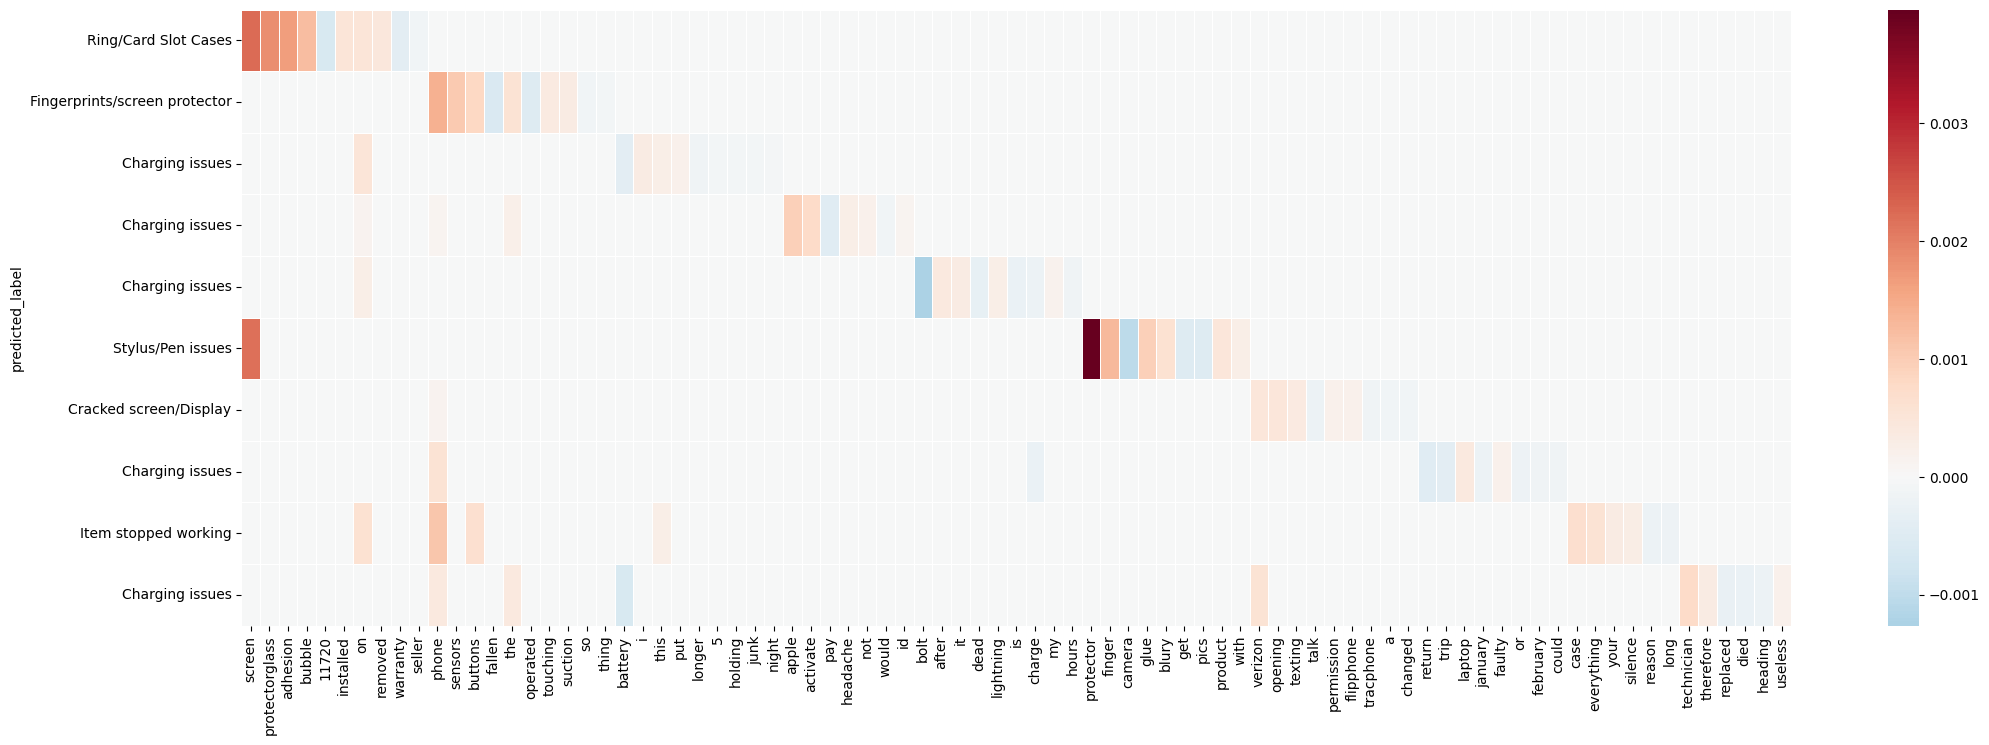

In [ ]:
plt.figure(figsize=(25,8))
sns.heatmap(data=numeric_weight_df,cmap='RdBu_r',center=0,xticklabels=True,yticklabels=True,linewidths=0.5)
# plt.savefig("../data/plots/lime_explainability_heatmap.png",dpi=150,bbox_inches='tight')
plt.show()

In [7]:
stylus_reviews = df[df['topic_label']=='Stylus/Pen issues']

In [11]:
mask = stylus_reviews['text'].str.contains('protector',case=False,na=False)

In [15]:
stylus_reviews = df[df['topic_label']=='Stylus/Pen issues']
protector_hits = stylus_reviews[mask]
print(len(protector_hits))
print(protector_hits['text'].head(5).values)

6
["The case fits the phone well and it is very pretty. However, if you want to take photos using the flash with your camera, the leather part of the case reflects onto the picture giving it a bluish hue (blue in my case since the case is blue). I use my camera extensively and ended up modifying the case by removing a good portion of the leather around the camera, flash, and laser focus so that it did not affect my photos.<br /><br />The leather also creates some difficulty in reaching the sensor. That part is not a big deal for me since I don't plan on using the finger sensor.<br /><br />I gave the case two stars because the rubber case inside actually does fit the phone well and I can easily remove the phone as needed. The length of the wrist strap is a nice length, and it will protect my phone screen. If you put cards in the slots, you may want to purchase a screen protector.<br /><br />This case (after my heavy modification) will work for now, but I am going to keep looking for ano

In [16]:
print(stylus_reviews['text'].sample(15,random_state=1).values)

["It looks and feel study. But I can't use it because it is very limited in the angle adjustment. Can't use it on the plane or on my desk which is why I bought it."
 'The camera covering will not come off except in tiny slivers and pieces. Unable to remove it. It has affected the quality of the photos. IT HAS TOTALLY RUINED AN EXPENSIVE PHONE. DO NOT BUY THIS ITEM. ON THE FRONT, IT PEALS OFF AND CHIPS WITH EASE. AWFUL PRODUCT! WE WANT TO SUE FOR DAMAGES!'
 'Don’t like the fact that I have to take off the case to take pictures when using flash it catches red glare from the case on pictures'
 'Seems so cheap. Camera cover is an open moving piece of plastic. Returning.'
 "The lenses didn't attach to the case due to incorrect molding on the case. After a great deal of careful modification I was able to get the lenses to mount. However the pictures with the lenses are distorted. The telephoto is not effective and tends to pincushion; the wide angle distortion is the opposite. The macro was 

In [18]:
print(stylus_reviews['topic_id'].unique())

[14]


## Phase 6 — LIME Explainability for Topic Classification

### Overview
Built a local explainability layer using LIME to answer: *"why was this
review assigned to this topic?"* at the word level. Rather than explaining
a trained classifier, LIME probes a **centroid-based similarity classifier**
built from pre-existing embeddings — no retraining required.

### Classifier Design (Centroid-Based)

Instead of training a traditional classifier, a nearest-centroid proxy was built:

- **Centroids:** For each topic, averaged the embeddings of all reviews
  belonging to that topic → one 384-dim centroid vector per topic
- **`predict_proba(texts)`:** Encodes input text → computes cosine similarity
  against all 39 topic centroids → applies softmax to produce a probability
  distribution
- **Model used:** `all-MiniLM-L6-v2` (same model used for original embeddings)
- **Output shape:** `(n, 39)` — one probability per topic per input text

This approach works because the centroids act as representative "average
complaints" per topic — a new review's topic is whichever centroid it sits
closest to in embedding space.

### LIME Setup

```python
explainer = LimeTextExplainer(class_names=topic_labels_sorted, random_state=42)
```

- **`num_features=10`** — top 10 most influential words extracted per review
- **`num_samples=500`** — 500 perturbed versions generated per explanation
- **Sample:** 10 reviews filtered to `word_count >= 20` and `topic_id != -1`
  (outliers excluded — they have no meaningful topic centroid)

### How LIME Works Internally

1. Takes a review and randomly **masks words** to generate 500 perturbed versions
2. Runs each version through `predict_proba` (treats it as a black box)
3. Fits a **local linear model** on the 500 (perturbation → probability) pairs
4. The linear model's coefficients are the **word weights** — positive means
   the word pushed the prediction toward the predicted topic, negative means
   it pushed away

### Data Pipeline

| Step | Output |
|------|--------|
| Run LIME on 10 reviews | `explaination_result` — list of 10 lists of `(word, weight)` tuples |
| Convert tuples to dicts | `explaination_dict_result` — list of 10 `{word: weight}` dicts |
| Get predicted label per review | `predicted_indexes` — argmax of `predict_proba` output |
| Combine into structured records | `heatmap_data` — list of 10 dicts with `review`, `predicted_label`, `weights` |
| Expand weights into columns | `weights_df` — shape `(10, 85)`, one column per unique word + 2 metadata columns |
| Set index for heatmap | `numeric_weight_df` — `predicted_label` as row index, 83 word columns |

### Heatmap

```python
sns.heatmap(data=numeric_weight_df, cmap='RdBu_r', center=0,
            xticklabels=True, yticklabels=True, linewidths=0.5)
```

- **Rows:** Individual reviews labeled by predicted topic
- **Columns:** 83 unique words across all 10 explanations
- **Red cell:** Word pushed prediction **toward** the predicted topic
- **Blue cell:** Word pushed prediction **away** from the predicted topic
- **White/empty cell:** Word not in top 10 features for that review (stored as 0)
- Saved to data/plots

### Key Observations from Heatmap
- Most rows are sparse — expected, since only 10 words are extracted per review
  out of 83 total unique words
- "Charging issues" appears 4 times as a row label — 4 of the 10 sampled
  reviews were classified into the same topic
- Strong red signals are localized — topic-specific words (e.g. "screen",
  "protectorglass" for Ring/Card Slot Cases) dominate individual rows with
  little cross-row overlap, confirming topic separation is meaningful

### Limitations
- **Sample size:** Only 10 reviews — patterns are illustrative, not statistically
  representative
- **LIME is slow:** 500 model calls per review; scaling to full 30K corpus is
  not feasible without parallelization or batching
- **`as_list()` scope:** Returns weights only for the predicted class — does not
  show how words influenced other topic probabilities
- **Duplicate row labels:** Multiple reviews sharing the same predicted topic
  appear as separate rows — no aggregation across same-topic reviews

## Discovery: LIME Exposed a Topic Mislabeling Bug

The heatmap above shows a single word, "protector," producing the strongest
signal on the entire map (~0.0035, more than double any other cell) for a
review predicted as **"Stylus/Pen issues."** This was unexpected — "protector"
has no obvious connection to a stylus.

**Investigation** (full detail in `chroma_db.ipynb`):
- Filtered all 237 reviews labeled "Stylus/Pen issues" for the word "protector" → 6 matches, all about camera lens/screen protectors, none about a stylus
- Sampled 15 reviews at random from the full topic → same pattern, camera lens/protector complaints dominate

**Root cause:** BERTopic's `reduce_topics(nr_topics=40)` step merged a small
camera-protector cluster into what was originally the stylus topic, and the
inherited label didn't reflect the merged content. Caught here, not during
topic modeling, because the centroid for this topic was built from
contaminated data and LIME faithfully reported what the centroid actually
represents — not what its name claimed.

**Fix:** Topic relabeled `"Stylus/Pen issues"` → `"Camera lens/protector issues"`
in `topic_labels`, `df['topic_label']`, and ChromaDB metadata (rebuilt
collection). `topic_centroids` required no change since it's keyed by
integer `topic_id`. See `chroma_db.ipynb` for full fix documentation.

**Why this matters:** This is the core value proposition of explainability
tooling — it didn't just explain a correct prediction, it surfaced a real
upstream data quality bug that survived topic modeling, manual label review,
and the original ChromaDB ingestion. LIME's local linear approximation is
faithful to the underlying model even when the model itself is flawed,
which is exactly what makes it useful for debugging, not just justification.

## Follow-up: Audit of Adjacent Topic Surfaced a Second Mislabel

After fixing the topic 14 mislabel above, the adjacent topic 17
("Camera/Camera lens issues") was manually audited for redundancy, since
both topics referenced cameras. It turned out to be a separate, unrelated
mislabel: topic 17's actual content was generic wear/durability complaints
(scratching, peeling) with no camera relevance at all — relabeled to
"Generic wear/durability complaints." Full investigation in
`topic_modelling.ipynb` and `chroma_db.ipynb`.

This wasn't found by LIME directly, but by following the same instinct
LIME's discovery triggered — checking neighboring topics for the same kind
of name/content mismatch. Two label corrections in one explainability pass
suggests the issue is systemic to `reduce_topics()` output rather than
isolated.